**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRE: Ernesto García González

*   MATRÍCULA: A00827434

*   NOMBRE: Felipe de Jesús Gamez Castellanos

*   MATRÍCULA: A01797817

*   NOMBRE: Carlos Humberto Galvan Perales

*   MATRÍCULA: A01797969

*   NOMBRE: Miguel Fernando García Piña

*   MATRÍCULA: A01046823

En esta actividad trabajarás con el archivo `diamonds_dataset.csv`, basado en un conjunto de datos sobre características de diamantes, disponible en el paquete ggplot2 de R y en repositorios públicos de análisis de datos.

Los datos fueron recopilados para analizar el precio de los diamantes en función de sus propiedades físicas y cualidades de corte, color y claridad. Los indicadores incluidos son:

* `carat`: Peso del diamante en quilates
* `cut`: Calidad del corte del diamante (Fair, Good, Very Good, Premium, Ideal)
* `color`: Color del diamante, de D (mejor) a J (peor)
* `clarity`: Claridad del diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
* `depth`: Profundidad total del diamante como porcentaje: z / mean(x, y)
* `table`: Ancho de la tabla del diamante como porcentaje de x
* `x`: Longitud en mm
* `y`: Ancho en mm
* `z`: Profundidad en mm
* `price`: Precio del diamante en dólares estadounidenses. Es la variable de salida o *target*

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score

1. Descarga el archivo: `diamonds_dataset.csv` y guarda, en un dataframe (`diamonds_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/1er Trimestre/Ciencia y Analítica de Datos/8.1 Aprendizaje Supervisado"
os.chdir(DIR)

Mounted at /content/drive


In [3]:
diamonds_df = pd.read_csv('diamonds_dataset.csv')

# Obtener resúmen de tipo de datos
print(diamonds_df.info())

# Determinar el número de columnas numéricas y de texto
numeric_cols = diamonds_df.select_dtypes(include=np.number).shape[1]
text_cols = diamonds_df.select_dtypes(include='object').shape[1]

print(f"\nNúmero de columnas numéricas: {numeric_cols}")
print(f"Número de columnas de texto: {text_cols}")

# Determinar la cantidad de valores únicos por columna
print("\nCantidad de valores únicos por columna:")
print(diamonds_df.nunique())

# Verificar si alguna columna contiene valores faltantes
print("\nValores faltantes por columna:")
print(diamonds_df.isnull().sum())

# Verificar y eliminar registros duplicados
print(f"\nNúmero de registros duplicados antes de eliminarlos: {diamonds_df.duplicated().sum()}")
diamonds_df.drop_duplicates(inplace=True);
diamonds_df.reset_index(drop=True, inplace=True);
print(f"Número de registros duplicados después de eliminarlos: {diamonds_df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53936 entries, 0 to 53935
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53936 non-null  float64
 1   cut      53936 non-null  object 
 2   color    53936 non-null  object 
 3   clarity  53936 non-null  object 
 4   depth    53936 non-null  float64
 5   table    53936 non-null  float64
 6   x        53936 non-null  float64
 7   y        53936 non-null  float64
 8   z        53936 non-null  float64
 9   price    53936 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB
None

Número de columnas numéricas: 7
Número de columnas de texto: 3

Cantidad de valores únicos por columna:
carat        271
cut            5
color          7
clarity        8
depth        184
table        127
x            551
y            551
z            372
price      11600
dtype: int64

Valores faltantes por columna:
carat      0
cut        0
color      0
clarity  

2. Obtén las estadísticas descriptivas, separando las variables numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Para las variables numéricas genera histogramas y boxplots para explorar la distribución y la dispersión.
* Para las variables categóricas utiliza diagramas de barras para visualizar la frecuencia de cada categoría.


Estadísticas descriptivas para variables numéricas:


,carat,depth,table,x,y,z,price
count,53790.000000,53790.000000,53790.000000,53790.000000,53790.000000,53790.000000,53790.000000
mean,0.797567,61.748007,57.457938,5.730916,5.734363,3.538524,3932.165793
std,0.472696,1.429789,2.233613,1.120187,1.140741,0.704699,3986.884865
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,951.000000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.030000,5324.750000
max,4.500000,79.000000,95.000000,10.230000,58.900000,31.800000,18823.000000



Estadísticas descriptivas para variables categóricas:


,cut,color,clarity
count,53790,53790,53790
unique,5,7,8
top,Ideal,G,SI1
freq,21488,11262,13032



Tablas de frecuencia para variables categóricas:

Frecuencia para la columna 'cut':


,count
cut,
Ideal,21488
Premium,13748
Very Good,12066
Good,4891
Fair,1597



Frecuencia para la columna 'color':


,count
color,
G,11262
E,9776
F,9520
H,8272
D,6754
I,5405
J,2801



Frecuencia para la columna 'clarity':


,count
clarity,
SI1,13032
VS2,12229
SI2,9148
VS1,8156
VVS2,5056
VVS1,3647
IF,1784
I1,738


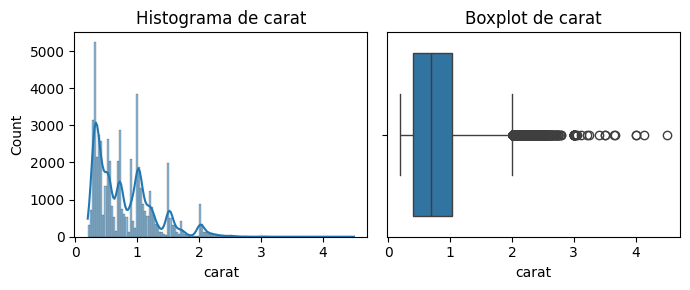

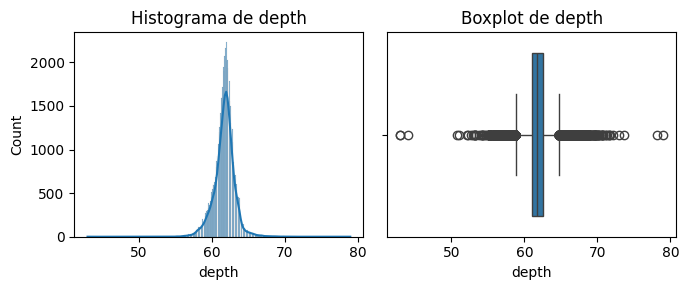

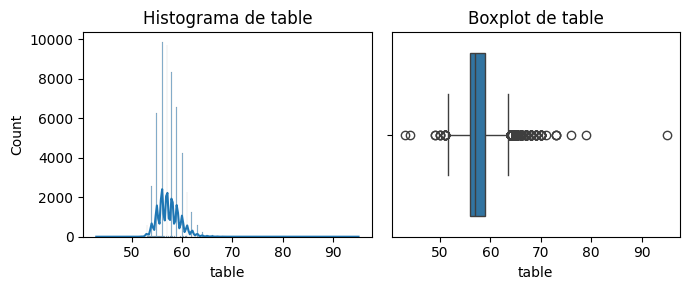

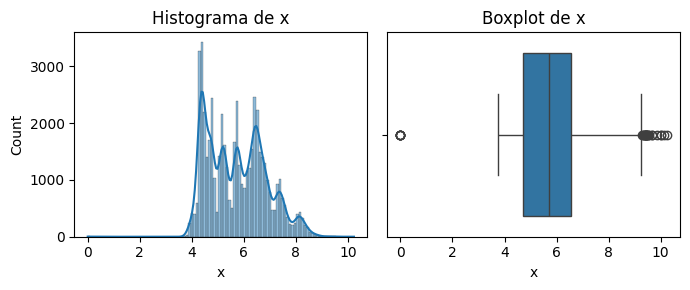

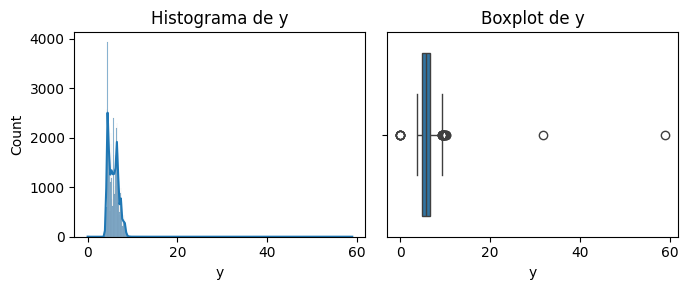

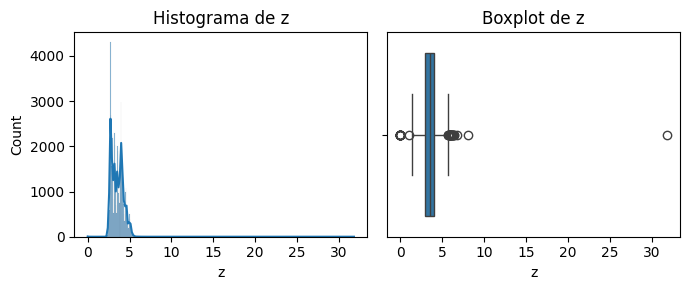

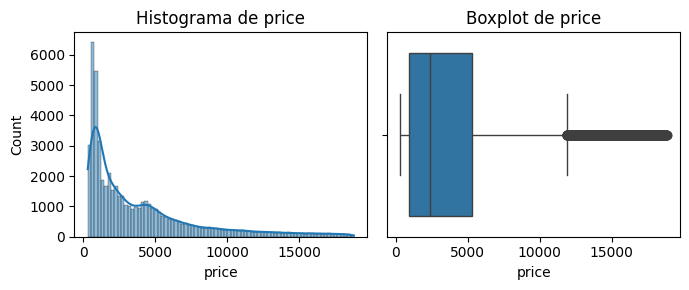

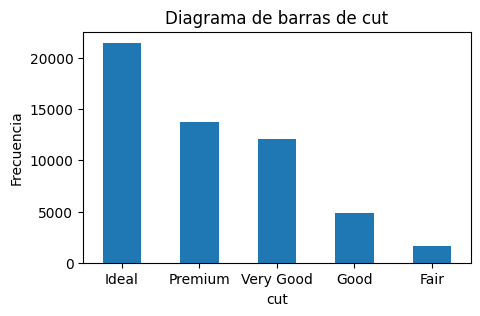

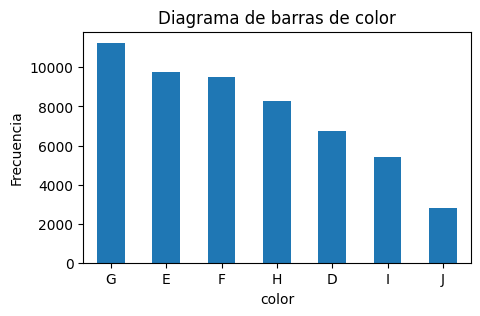

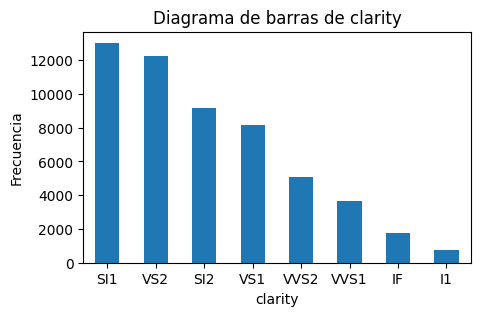

In [4]:
# Obtener estadísticas descriptivas para variables numéricas
print("\nEstadísticas descriptivas para variables numéricas:")
display(diamonds_df.describe())

# Obtener estadísticas descriptivas para variables categóricas y tablas de frecuencia
print("\nEstadísticas descriptivas para variables categóricas:")
display(diamonds_df.describe(include='object'))

print("\nTablas de frecuencia para variables categóricas:")
for col in diamonds_df.select_dtypes(include='object').columns:
    print(f"\nFrecuencia para la columna '{col}':")
    display(diamonds_df[col].value_counts())

# Generar histogramas y boxplots para variables numéricas
numeric_cols = diamonds_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    sns.histplot(data=diamonds_df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    sns.boxplot(data=diamonds_df, x=col, ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()

# Generar diagramas de barras para variables categóricas
categorical_cols = diamonds_df.select_dtypes(include='object').columns
for col in categorical_cols:
    plt.figure(figsize=(5, 3))
    diamonds_df[col].value_counts().plot(kind='bar')
    plt.title(f'Diagrama de barras de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=0)
    plt.show()

3. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Boxplots que muestren la distribución del precio para cada categoría de color, asegurándose de que las categorías se muestren en el orden de calidad de diamante de mejor a peor: D, E, F, G, H, I, J.
* ¿La tendencia de los precios se comporta como esperabas? Identifica si alguna otra variable podría estar influyendo en la tendencia observada por color y comenta tus observaciones.
* Gráfico de dispersión del precio frente al peso de los diamantes, coloreando los puntos según la categoría de calidad del corte.
* ¿Qué relación se observa entre el peso del diamante y su precio según la calidad del corte?

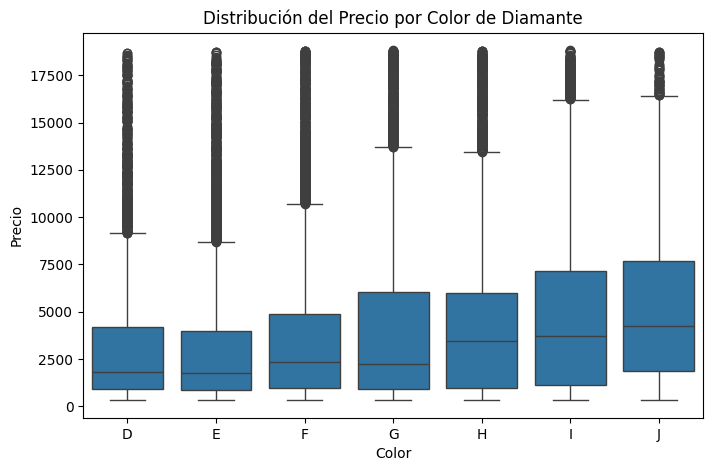

In [5]:
# Definir el orden de las categorías de color
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

# Generar boxplot de precio por color
plt.figure(figsize=(8, 5))
sns.boxplot(data=diamonds_df, x='color', y='price', order=color_order)
plt.title('Distribución del Precio por Color de Diamante')
plt.xlabel('Color')
plt.ylabel('Precio')
plt.show()



In [6]:
# La tendencia del color respecto al precio no es como esperado.
# Para identificar la variable que afecta esta tendencia, se observará la correlación de estas con el precio.

# Calcular la matriz de correlación
correlation_matrix = diamonds_df.select_dtypes(include=np.number).corr()

# Mostrar la correlación de todas las variables con 'price'
print("Correlación con 'price':")
display(correlation_matrix['price'].sort_values(ascending=False))

Correlación con 'price':


,price
price,1.000000
carat,0.921845
x,0.884423
y,0.865297
z,0.861114
table,0.126397
depth,-0.011240


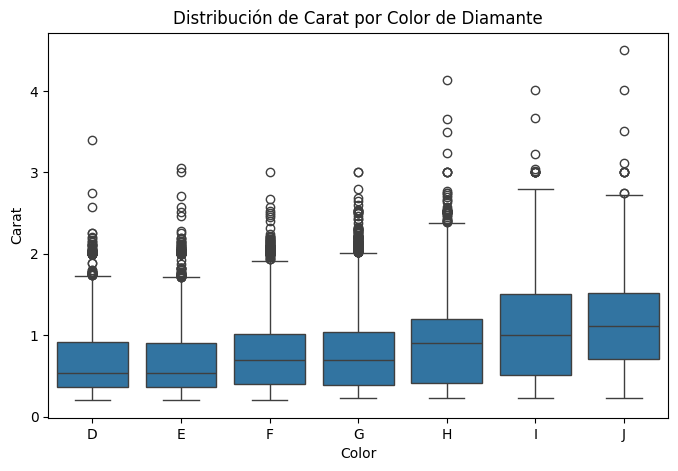

In [7]:
# Se detectó que la variable que mas afecta al precio es "carat", es decir, el peso.
# Buscaremos evaluar si existe alguna relación entre el peso y el color.

# Generar boxplot de carat por color
plt.figure(figsize=(8, 5))
sns.boxplot(data=diamonds_df, x='color', y='carat', order=color_order)
plt.title('Distribución de Carat por Color de Diamante')
plt.xlabel('Color')
plt.ylabel('Carat')
plt.show()

**Observaciones sobre la influencia del peso en la relación color-precio:**

Basándome en los gráficos de boxplot que generamos (precio por color y quilate por color), observamos que la distribución de precios por color no seguía la tendencia esperada (los colores de mejor calidad D, E, F no mostraban consistentemente los precios más altos). Al analizar la distribución de `carat` por color, notamos que los diamantes con colores de menor calidad (como I y J) tienden a tener un rango de pesos (`carat`) mayor en comparación con los diamantes de colores de mejor calidad (D, E, F).

Dado que el peso (`carat`) tiene una correlación muy alta con el precio, este hallazgo explica por qué los diamantes de colores de menor calidad pueden tener precios más altos en promedio a pesar de su color.

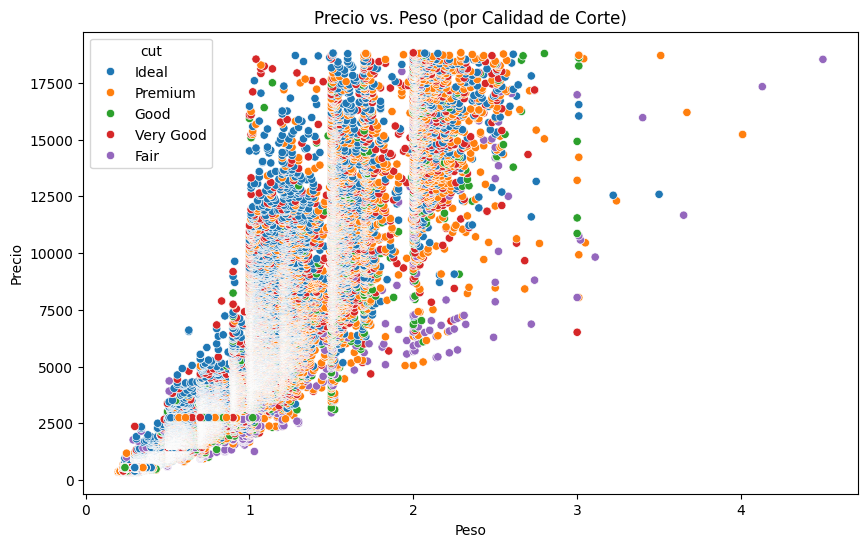

In [8]:
# Generar gráfico de dispersión de precio vs. peso, coloreado por corte
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diamonds_df, x='carat', y='price', hue='cut')
plt.title('Precio vs. Peso (por Calidad de Corte)')
plt.xlabel('Peso')
plt.ylabel('Precio')
plt.show()

**Observaciones sobre la relación entre peso, precio y calidad del corte:**

Con base en el gráfico de dispersión del precio frente al peso, se observa una fuerte relación positiva entre el peso del diamante y su precio. A medida que aumenta el peso del diamante, el precio tiende a aumentar significativamente.

La calidad del corte (`cut`) también parece influir en esta relación. Para un mismo peso, los diamantes con mejor calidad de corte (Ideal, Premium, Very Good) tienden a tener precios ligeramente más altos en comparación con los de menor calidad (Good, Fair). Sin embargo, la influencia del peso es mucho más pronunciada que la de la calidad del corte en la determinación del precio.

4. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Analiza la correlación entre los predictores (excluyendo `price`), identifica si un único predictor captura información que también está presente en varios otros y elimina los predictores redundantes para simplificar la complejidad de los modelos que construirás más adelante.
* Vuelve a generar el mapa de calor para verificar que ya no queden predictores altamente correlacionados.

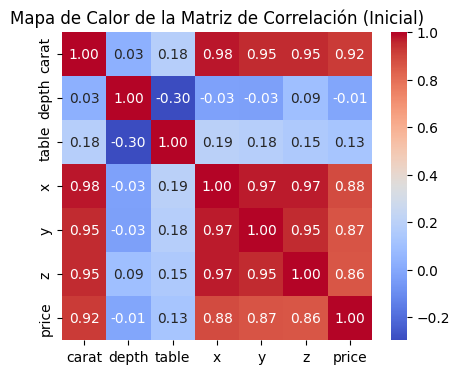


Pares de variables con correlación superior a 0.9:
carat - x: 0.98
carat - y: 0.95
x - y: 0.97
carat - z: 0.95
x - z: 0.97
y - z: 0.95
carat - price: 0.92

Columnas eliminadas debido a alta correlación: ['x', 'y', 'z']


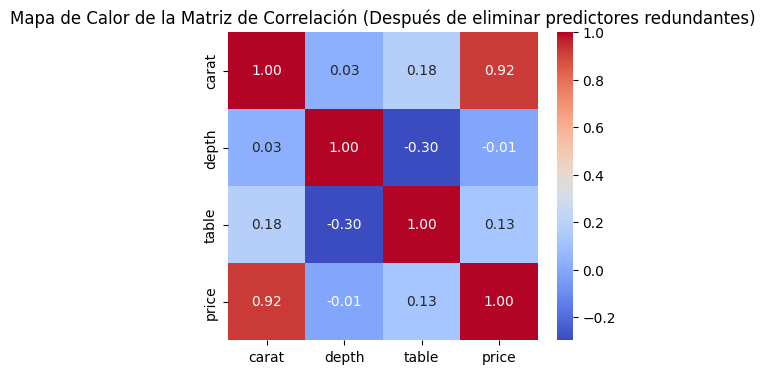

In [9]:
# Calcular la matriz de correlación para variables numéricas
correlation_matrix = diamonds_df.select_dtypes(include=np.number).corr()

# Generar el mapa de calor
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación (Inicial)')
plt.show()

# Identificar pares de variables con correlación superior a 0.9
highly_correlated_pairs = []
# Usar abs() para obtener el valor absoluto de la correlación
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
for col in upper.columns:
    for row in upper.index:
        if abs(upper.loc[row, col]) > 0.9:
            highly_correlated_pairs.append((row, col, upper.loc[row, col]))

print("\nPares de variables con correlación superior a 0.9:")
for pair in highly_correlated_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

# Analizar la correlación entre los predictores (excluyendo 'price')
predictors_corr = diamonds_df.select_dtypes(include=np.number).drop(columns=['price']).corr()

# Identificar predictores redundantes
# Basado en el mapa de calor inicial, 'x', 'y', y 'z' están altamente correlacionados con 'carat'y entre sí.
# De igual forma los predictores 'table y 'depth' son variables mas complejas que salen de cálculos con 'x', 'y', y 'z'
# Eliminaremos 'x', 'y', y 'z' ya que su información parece estar capturada por 'carat' y están fuertemente correlacionados entre sí.
columns_to_drop = ['x', 'y', 'z']
diamonds_df_reduced = diamonds_df.drop(columns=columns_to_drop)

print(f"\nColumnas eliminadas debido a alta correlación: {columns_to_drop}")

# Vuelve a generar el mapa de calor para verificar
correlation_matrix_reduced = diamonds_df_reduced.select_dtypes(include=np.number).corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix_reduced, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación (Después de eliminar predictores redundantes)')
plt.show()

5. Construye un modelo de regresión simple utilizando únicamente la variable predictora que tenga la mayor correlación con `price`. Para ello:
* Asigna esta variable a `X` y `price` a `y` y divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Entrena un modelo con `LinearRegression()` de scikit-learn y evalúalo en el conjunto de prueba utilizando las métricas `RMSE` (Root Mean Squared Error) y `R²` (coeficiente de determinación).
* Añade los valores obtenidos a un dataframe de resultados, que incluya el nombre del modelo (*Baseline*) y una columna para cada métrica.
* Muestra la ecuación de la regresión lineal utilizando el intercepto y el coeficiente asociado al predictor. La ecuación debe tener la forma:
> `price = intercepto + coeficiente × predictor`

In [10]:
# Identificar la variable predictora con la mayor correlación con 'price'
# Excluir 'price' de las correlaciones con price para encontrar el mejor predictor
correlation_with_price = correlation_matrix_reduced['price'].drop('price')
best_predictor = correlation_with_price.abs().idxmax()

print(f"La variable predictora con la mayor correlación absoluta con 'price' es: {best_predictor}")

# Asignar la variable predictora a X y 'price' a y
X = diamonds_df_reduced[[best_predictor]]
y = diamonds_df_reduced['price']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Entrenar un modelo de regresión lineal
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_baseline = model_baseline.predict(X_test)

# Evaluar el modelo
rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

# Crear un dataframe para almacenar los resultados
results_df = pd.DataFrame({
    'Modelo': ['Baseline'],
    'RMSE': [rmse_baseline],
    'R²': [r2_baseline]
})

print("\nResultados del modelo Baseline:")
display(results_df)

# Mostrar la ecuación de la regresión lineal
intercept_baseline = model_baseline.intercept_
coefficient_baseline = model_baseline.coef_[0]

print(f"\nEcuación de la regresión lineal (Modelo Baseline):")
print(f"price = {intercept_baseline:.2f} + {coefficient_baseline:.2f} × {best_predictor}")

La variable predictora con la mayor correlación absoluta con 'price' es: carat

Resultados del modelo Baseline:


,Modelo,RMSE,R²
0,Baseline,1552.846192,0.843757



Ecuación de la regresión lineal (Modelo Baseline):
price = -2263.12 + 7775.23 × carat


6. Utiliza todas las variables como predictoras para crear un segundo modelo:
* Haz la asignación correspondiente en `X` y `y` y divide en entrenamiento y prueba usando la misma configuración del ejercicio anterior.
* Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento robusto a los predictores numéricos y codificación ordinal a los categóricos. Asegúrate de respetar el orden correcto de cada categoría, tal como se indica en la descripción de las variables.
* Construye un pipeline que combine el transformador creado con un modelo de regresión lineal.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Ordinal_Robust*.

In [11]:
# Asignar todas las variables (excepto 'price') a X y 'price' a y
X = diamonds_df.drop(columns=['price'])
y = diamonds_df['price']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Definir los ordenes para la codificación ordinal
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Crear el transformador para escalamiento robusto y codificación ordinal
preprocessing = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), make_column_selector(dtype_include=np.number)),
        ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), make_column_selector(dtype_include='object'))
    ],
    remainder='passthrough' # Mantener otras columnas si las hubiera
)

# Construir el pipeline
model_ordinal_robust = make_pipeline(
    preprocessing,
    LinearRegression()
)

# Entrenar el modelo
model_ordinal_robust.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_ordinal_robust = model_ordinal_robust.predict(X_test)

# Evaluar el modelo
rmse_ordinal_robust = root_mean_squared_error(y_test, y_pred_ordinal_robust)
r2_ordinal_robust = r2_score(y_test, y_pred_ordinal_robust)

# Añadir los resultados al dataframe de resultados
results_df = pd.concat([results_df, pd.DataFrame({
    'Modelo': ['Ordinal_Robust'],
    'RMSE': [rmse_ordinal_robust],
    'R²': [r2_ordinal_robust]
})], ignore_index=True)

print("\nResultados del modelo Ordinal_Robust:")
display(results_df)


Resultados del modelo Ordinal_Robust:


,Modelo,RMSE,R²
0,Baseline,1552.846192,0.843757
1,Ordinal_Robust,1194.947284,0.907479


7. Prepara otro transformador, llamado `preprocessing2`, que aplique escalamiento Min-Max a los predictores numéricos y codificación one-hot a los categóricos, asegurando `drop='first'` para prevenir multicolinealidad en las variables dummies generadas.
* Construye otro pipeline utilizando este nuevo transformador y, a continuación, entrena y evalúa el modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *OHE_MinMax*.

In [12]:
# Crear el transformador para escalamiento Min-Max y codificación one-hot
preprocessing2 = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), make_column_selector(dtype_include=np.number)),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), make_column_selector(dtype_include='object'))
    ],
    remainder='passthrough'
)

# Construir el pipeline
model_ohe_minmax = make_pipeline(
    preprocessing2,
    LinearRegression()
)

# Entrenar el modelo
model_ohe_minmax.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_ohe_minmax = model_ohe_minmax.predict(X_test)

# Evaluar el modelo
rmse_ohe_minmax = root_mean_squared_error(y_test, y_pred_ohe_minmax)
r2_ohe_minmax = r2_score(y_test, y_pred_ohe_minmax)

# Añadir los resultados al dataframe de resultados
results_df = pd.concat([results_df, pd.DataFrame({
    'Modelo': ['OHE_MinMax'],
    'RMSE': [rmse_ohe_minmax],
    'R²': [r2_ohe_minmax]
})], ignore_index=True)

print("\nResultados del modelo OHE_MinMax:")
display(results_df)


Resultados del modelo OHE_MinMax:


,Modelo,RMSE,R²
0,Baseline,1552.846192,0.843757
1,Ordinal_Robust,1194.947284,0.907479
2,OHE_MinMax,1104.366811,0.920974


8. Modifica el pipeline anterior para emplear regresión polinomial de segundo grado y evalúa si esto mejora el ajuste del modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *PolynomialDegree2*.

In [13]:
# Modificar el pipeline anterior para incluir regresión polinomial de segundo grado
model_polynomial_degree2 = make_pipeline(
    preprocessing2, # Usar el mismo preprocesamiento OHE_MinMax
    PolynomialFeatures(degree=2),
    LinearRegression()
)

# Entrenar el modelo
model_polynomial_degree2.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_polynomial_degree2 = model_polynomial_degree2.predict(X_test)

# Evaluar el modelo
rmse_polynomial_degree2 = root_mean_squared_error(y_test, y_pred_polynomial_degree2)
r2_polynomial_degree2 = r2_score(y_test, y_pred_polynomial_degree2)

# Añadir los resultados al dataframe de resultados
results_df = pd.concat([results_df, pd.DataFrame({
    'Modelo': ['PolynomialDegree2'],
    'RMSE': [rmse_polynomial_degree2],
    'R²': [r2_polynomial_degree2]
})], ignore_index=True)

print("\nResultados del modelo PolynomialDegree2:")
display(results_df)


Resultados del modelo PolynomialDegree2:


,Modelo,RMSE,R²
0,Baseline,1552.846192,0.843757
1,Ordinal_Robust,1194.947284,0.907479
2,OHE_MinMax,1104.366811,0.920974
3,PolynomialDegree2,694.941880,0.968708


9. Ordena el dataframe de resultados según el `R²`, de manera que el modelo con mejor desempeño aparezca primero.
* Para dicho modelo, crea un gráfico de dispersión de los valores reales frente a los predichos, e incluye una línea diagonal de referencia para indicar una predicción perfecta.

Resultados de los modelos ordenados por R²:


,Modelo,RMSE,R²
0,PolynomialDegree2,694.941880,0.968708
1,OHE_MinMax,1104.366811,0.920974
2,Ordinal_Robust,1194.947284,0.907479
3,Baseline,1552.846192,0.843757


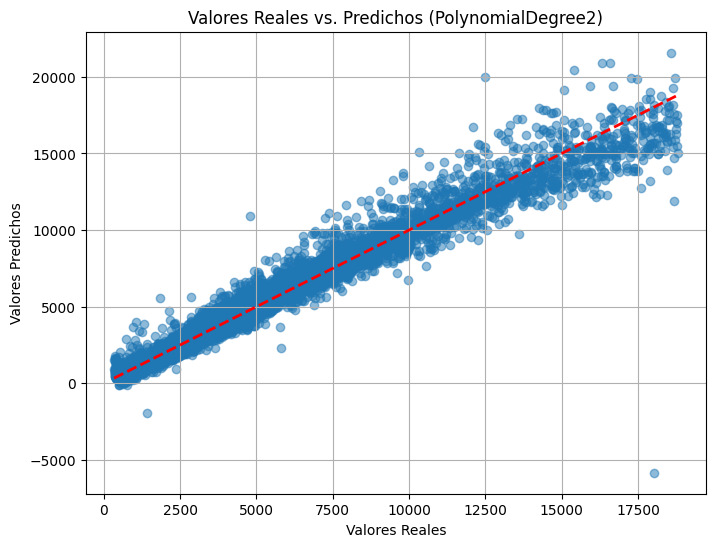

In [14]:
# Ordenar el dataframe de resultados por R² de forma descendente
results_df_sorted = results_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

print("Resultados de los modelos ordenados por R²:")
display(results_df_sorted)

# Identificar el mejor modelo
best_model_name = results_df_sorted.iloc[0]['Modelo']

# Obtener las predicciones del mejor modelo
if best_model_name == 'Baseline':
    y_pred_best = y_pred_baseline
elif best_model_name == 'Ordinal_Robust':
    y_pred_best = y_pred_ordinal_robust
elif best_model_name == 'OHE_MinMax':
    y_pred_best = y_pred_ohe_minmax
elif best_model_name == 'PolynomialDegree2':
    y_pred_best = y_pred_polynomial_degree2
else:
    y_pred_best = None

if y_pred_best is not None:
    # Crear gráfico de dispersión de valores reales frente a predichos para el mejor modelo
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred_best, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea de referencia
    plt.xlabel('Valores Reales')
    plt.ylabel('Valores Predichos')
    plt.title(f'Valores Reales vs. Predichos ({best_model_name})')
    plt.grid(True)
    plt.show()
else:
    print(f"No se encontraron predicciones para el mejor modelo: {best_model_name}")

10. Muestra la representación gráfica del pipeline para ubicar la posición de cada elemento dentro del flujo del modelo.
* Obtén los nombres de todas las columnas después del preprocesamiento (numéricas y dummies de categóricas).
* Extrae los nombres de las columnas polinómicas.
* Recupera los coeficientes y el intercepto del modelo de regresión lineal.
* Ordena los coeficientes por su valor absoluto para mostrar los 10 más importantes y da conclusiones sobre cómo los distintos factores influyen en el precio.

In [15]:
from sklearn import set_config
set_config(display='diagram')

# Muestra la representación gráfica del pipeline del mejor modelo
print("Representación gráfica del pipeline del mejor modelo:")
display(model_polynomial_degree2) # Assuming PolynomialDegree2 is the best model based on previous results

# Obtener los nombres de las columnas después del preprocesamiento
# Esto requiere acceder al paso de ColumnTransformer y obtener los nombres de las características transformadas
preprocessor = model_polynomial_degree2.named_steps['columntransformer']

# Obtener los nombres de las columnas numéricas originales
numeric_features = preprocessor.transformers_[0][2]

# Obtener los nombres de las columnas categóricas después de One-Hot Encoding
categorical_transformer = preprocessor.transformers_[1][1]
categorical_features_ohe = categorical_transformer.get_feature_names_out(preprocessor.transformers_[1][2])

# Combinar los nombres de las columnas numéricas y categóricas preprocesadas
all_processed_features = list(numeric_features) + list(categorical_features_ohe)

# Obtener los nombres de las columnas después de la transformación polinómica
polynomial_transformer = model_polynomial_degree2.named_steps['polynomialfeatures']
feature_names_after_poly = polynomial_transformer.get_feature_names_out(all_processed_features)

print("\nNombres de las columnas después del preprocesamiento y transformación polinómica:")
print(feature_names_after_poly)

# Recuperar los coeficientes y el intercepto del modelo de regresión lineal
linear_regression_model = model_polynomial_degree2.named_steps['linearregression']
coefficients = linear_regression_model.coef_
intercept = linear_regression_model.intercept_

print(f"\nIntercepto del modelo de regresión lineal: {intercept:.2f}")

# Crear un DataFrame para mostrar los coeficientes con sus nombres
coefficients_df = pd.DataFrame({
    'Feature': feature_names_after_poly,
    'Coefficient': coefficients
})

# Ordenar los coeficientes por su valor absoluto y mostrar los 10 más importantes
coefficients_df['Abs_Coefficient'] = abs(coefficients_df['Coefficient'])
coefficients_df_sorted = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

print("\nLos 10 coeficientes más importantes (ordenados por valor absoluto):")
display(coefficients_df_sorted.head(10))

Representación gráfica del pipeline del mejor modelo:


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', MinMaxScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5b10a826f0>),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c5b07da3230>)])),
                ('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])


Nombres de las columnas después del preprocesamiento y transformación polinómica:
['1' 'carat' 'depth' 'table' 'x' 'y' 'z' 'cut_Good' 'cut_Ideal'
 'cut_Premium' 'cut_Very Good' 'color_E' 'color_F' 'color_G' 'color_H'
 'color_I' 'color_J' 'clarity_IF' 'clarity_SI1' 'clarity_SI2'
 'clarity_VS1' 'clarity_VS2' 'clarity_VVS1' 'clarity_VVS2' 'carat^2'
 'carat depth' 'carat table' 'carat x' 'carat y' 'carat z'
 'carat cut_Good' 'carat cut_Ideal' 'carat cut_Premium'
 'carat cut_Very Good' 'carat color_E' 'carat color_F' 'carat color_G'
 'carat color_H' 'carat color_I' 'carat color_J' 'carat clarity_IF'
 'carat clarity_SI1' 'carat clarity_SI2' 'carat clarity_VS1'
 'carat clarity_VS2' 'carat clarity_VVS1' 'carat clarity_VVS2' 'depth^2'
 'depth table' 'depth x' 'depth y' 'depth z' 'depth cut_Good'
 'depth cut_Ideal' 'depth cut_Premium' 'depth cut_Very Good'
 'depth color_E' 'depth color_F' 'depth color_G' 'depth color_H'
 'depth color_I' 'depth color_J' 'depth clarity_IF' 'depth clarity_SI1'
 'd

,Feature,Coefficient,Abs_Coefficient
28,carat y,1.232667e+06,1.232667e+06
111,y z,1.164393e+06,1.164393e+06
92,x z,-6.818183e+05,6.818183e+05
110,y^2,-5.335506e+05,5.335506e+05
29,carat z,3.311071e+05,3.311071e+05
71,table y,-2.786712e+05,2.786712e+05
91,x y,2.287519e+05,2.287519e+05
6,z,2.169647e+05,2.169647e+05
50,depth y,-2.017911e+05,2.017911e+05
127,y clarity_VVS1,-1.976868e+05,1.976868e+05


**Conclusiones sobre la influencia de los distintos factores en el precio:**

Los coeficientes indican la magnitud y dirección de la relación entre cada característica (después de la transformación polinómica) y el precio, manteniendo las otras características constantes.
Un coeficiente positivo alto sugiere que un aumento en el valor de esa característica está asociado con un aumento significativo en el precio.
Un coeficiente negativo alto sugiere que un aumento en el valor de esa característica está asociado con una disminución significativa en el precio.
Los coeficientes con valores absolutos más grandes (mostrados arriba) son los que tienen un mayor impacto en la predicción del precio en este modelo.
